# EEG Emotion Classification — CNN sulle feature v5

CNN multi-input che riceve in pasto le **580 feature v5** (`dataset_v5_features.csv`), divise nelle due famiglie naturali:

- **DE** (310 feature) → reshape come `(62 canali, 5 bande, 1)` → ramo **Conv2D** che impara pattern spazio-spettrali sulla griglia canale × banda.
- **DASM + RASM** (135 + 135 = 270 feature) → ramo flat normalizzato che entra direttamente nel classificatore Dense.

I due rami vengono concatenati prima della testa di classificazione. L'intera architettura è definita in un solo blocco con la **Functional API** (no `.add()`).

> Prerequisito: `Feature_Extraction_v5.ipynb` (genera `dataset_v5_features.csv`).

> ⚠️ **Caveat sull'affidabilità del test accuracy.** Lo split casuale stratificato lascia gli stessi 3 pazienti in train, val e test, e finestre da 1.5 s adiacenti dello stesso video clip finiscono in fold diversi. La CNN può facilmente sfruttare la "firma" neurale del soggetto e l'autocorrelazione temporale tra finestre vicine. Una accuracy ~80–90 % qui è coerente con il subject-fingerprinting già visto nei baseline shallow sullo stesso split (RF v5 = 86.4 %). Per una stima onesta serve un protocollo **leave-one-subject-out**.

In [2]:
# ==========================================
# IMPORTS & SETUP
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Dropout, Flatten, Dense, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Riproducibilità
np.random.seed(42)
tf.random.set_seed(42)

EMOTION_LABELS = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']
NUM_CLASSES    = 5

## 1. Caricamento dati

Carichiamo i tre split precomputed da `data/splitted/` (`eeg_train.csv`, `eeg_val.csv`, `eeg_test.csv`) e separiamo:

- 310 colonne `DE_*` → reshape a `(62, 5, 1)` per il ramo Conv2D
- 270 colonne `DASM_*` + `RASM_*` → vettore flat per il ramo tabulare

Lo split **70 / 15 / 15** è già stato applicato in `Preprocessing.ipynb` con stratificazione e `random_state=42`.

In [3]:
# ==========================================
# 1. CARICAMENTO DA SPLIT PRECOMPUTED (data/splitted/)
# ==========================================
SPLIT_DIR = '../data/splitted/'

df_train = pd.read_csv(SPLIT_DIR + 'eeg_train.csv')
df_val   = pd.read_csv(SPLIT_DIR + 'eeg_val.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'eeg_test.csv')

print(f'Train: {df_train.shape}  |  Val: {df_val.shape}  |  Test: {df_test.shape}')

DE_COLS   = [c for c in df_train.columns if c.startswith('DE_')]
DASM_COLS = [c for c in df_train.columns if c.startswith('DASM_')]
RASM_COLS = [c for c in df_train.columns if c.startswith('RASM_')]
print(f'DE: {len(DE_COLS)}  |  DASM: {len(DASM_COLS)}  |  RASM: {len(RASM_COLS)}')

# DE reshape come griglia canale × banda (ordine colonne: canale-outer, banda-inner)
Xde_train = df_train[DE_COLS].values.astype(np.float32).reshape(-1, 62, 5, 1)
Xa_train  = df_train[DASM_COLS + RASM_COLS].values.astype(np.float32)
y_train   = to_categorical(df_train['Label'].values.astype(int), num_classes=NUM_CLASSES)

Xde_val   = df_val[DE_COLS].values.astype(np.float32).reshape(-1, 62, 5, 1)
Xa_val    = df_val[DASM_COLS + RASM_COLS].values.astype(np.float32)
y_val     = to_categorical(df_val['Label'].values.astype(int), num_classes=NUM_CLASSES)

Xde_test  = df_test[DE_COLS].values.astype(np.float32).reshape(-1, 62, 5, 1)
Xa_test   = df_test[DASM_COLS + RASM_COLS].values.astype(np.float32)
y_test    = to_categorical(df_test['Label'].values.astype(int), num_classes=NUM_CLASSES)

print(f'\nTrain: DE {Xde_train.shape}  ASYM {Xa_train.shape}  y {y_train.shape}')
print(f'Val  : DE {Xde_val.shape}    ASYM {Xa_val.shape}    y {y_val.shape}')
print(f'Test : DE {Xde_test.shape}   ASYM {Xa_test.shape}   y {y_test.shape}')

# df5: dataframe completo ricombinato (usato dalla sezione LOSO per Patient_ID / gruppi)
df5    = pd.concat([df_train, df_val, df_test], ignore_index=True)
X_asym = df5[DASM_COLS + RASM_COLS].values.astype(np.float32)  # shape reference per build_cnn

Train: (9374, 584)  |  Val: (2009, 584)  |  Test: (2009, 584)
DE: 310  |  DASM: 135  |  RASM: 135

Train: DE (9374, 62, 5, 1)  ASYM (9374, 270)  y (9374, 5)
Val  : DE (2009, 62, 5, 1)    ASYM (2009, 270)    y (2009, 5)
Test : DE (2009, 62, 5, 1)   ASYM (2009, 270)   y (2009, 5)


## 2. CNN multi-input

Architettura definita in un'unica catena Functional API:

| Ramo | Input → Layer chain                                                                                | Output dim |
|------|----------------------------------------------------------------------------------------------------|------------|
| DE   | `(62,5,1)` → BN → Conv2D(16,(1,3)) → BN → Drop → Conv2D(32,(62,1)) → BN → Drop → Flatten           | 32         |
| ASYM | `(270,)` → BN                                                                                       | 270        |
| Head | Concat → Dense(64) → Drop → Dense(5, softmax)                                                       | 5          |

- Il `Conv2D(16,(1,3))` impara pattern locali tra **bande adiacenti** dentro lo stesso canale.
- Il `Conv2D(32,(62,1))` integra l'attivazione **lungo l'asse spaziale** (collassa tutti i 62 canali in un vettore di 32 feature spaziali per banda).
- I `BatchNormalization` iniziali su entrambi i rami sostituiscono uno `StandardScaler` lato preprocessing.

Loss `categorical_crossentropy`, ottimizzatore `Adam` (`lr=1e-3`), `EarlyStopping` (patience 8) + `ReduceLROnPlateau` (factor 0.5, patience 4).

In [4]:
# ==========================================
# 2.1 Architettura CNN multi-input (Functional API)
# ==========================================
input_de   = Input(shape=(62, 5, 1),           name='de_input')
input_asym = Input(shape=(X_asym.shape[1],),   name='asym_input')

# Ramo Conv2D sulle DE (struttura canali × bande)
x = BatchNormalization(name='bn_de_input')(input_de)
x = Conv2D(16, (1, 3), padding='same', activation='relu', name='band_conv')(x)
x = BatchNormalization(name='bn_1')(x)
x = Dropout(0.2, name='drop_1')(x)
x = Conv2D(32, (62, 1), padding='valid', activation='relu', name='spatial_conv')(x)
x = BatchNormalization(name='bn_2')(x)
x = Dropout(0.3, name='drop_2')(x)
x = Flatten(name='flatten')(x)

# Ramo tabulare per DASM + RASM
y = BatchNormalization(name='bn_asym')(input_asym)

# Concatenazione + testa di classificazione
z = Concatenate(name='merge')([x, y])
z = Dense(64, activation='relu', name='dense_hidden')(z)
z = Dropout(0.3, name='drop_classifier')(z)
output = Dense(NUM_CLASSES, activation='softmax', name='output')(z)

cnn = Model(inputs=[input_de, input_asym], outputs=output, name='EEG_v5_CNN')
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
cnn.summary()



Model: "EEG_v5_CNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 de_input (InputLayer)       [(None, 62, 5, 1)]           0         []                            
                                                                                                  
 bn_de_input (BatchNormaliz  (None, 62, 5, 1)             4         ['de_input[0][0]']            
 ation)                                                                                           
                                                                                                  
 band_conv (Conv2D)          (None, 62, 5, 16)            64        ['bn_de_input[0][0]']         
                                                                                                  
 bn_1 (BatchNormalization)   (None, 62, 5, 16)            64        ['band_conv[0][0]']

In [5]:
# ==========================================
# 2.2 Training
# ==========================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]
history = cnn.fit(
    [Xde_train, Xa_train], y_train,
    validation_data=([Xde_val, Xa_val], y_val),
    epochs=50, batch_size=32,
    callbacks=callbacks, verbose=1,
)

Epoch 1/50


293/293 [==============================] - 8s 15ms/step - loss: 1.2633 - accuracy: 0.4836 - val_loss: 1.0548 - val_accuracy: 0.6008 - lr: 0.0010
Epoch 2/50
293/293 [==============================] - 7s 24ms/step - loss: 0.9140 - accuracy: 0.6367 - val_loss: 0.7553 - val_accuracy: 0.7193 - lr: 0.0010
Epoch 3/50
293/293 [==============================] - 7s 24ms/step - loss: 0.7756 - accuracy: 0.7012 - val_loss: 0.6180 - val_accuracy: 0.7725 - lr: 0.0010
Epoch 4/50
293/293 [==============================] - 5s 17ms/step - loss: 0.6735 - accuracy: 0.7383 - val_loss: 0.5485 - val_accuracy: 0.8084 - lr: 0.0010
Epoch 5/50
293/293 [==============================] - 5s 19ms/step - loss: 0.6292 - accuracy: 0.7619 - val_loss: 0.5209 - val_accuracy: 0.8123 - lr: 0.0010
Epoch 6/50
293/293 [==============================] - 8s 26ms/step - loss: 0.5831 - accuracy: 0.7831 - val_loss: 0.4966 - val_accuracy: 0.8173 - lr: 0.0010
Epoch 7/50
293/293 [==============================] - 8s 27ms/

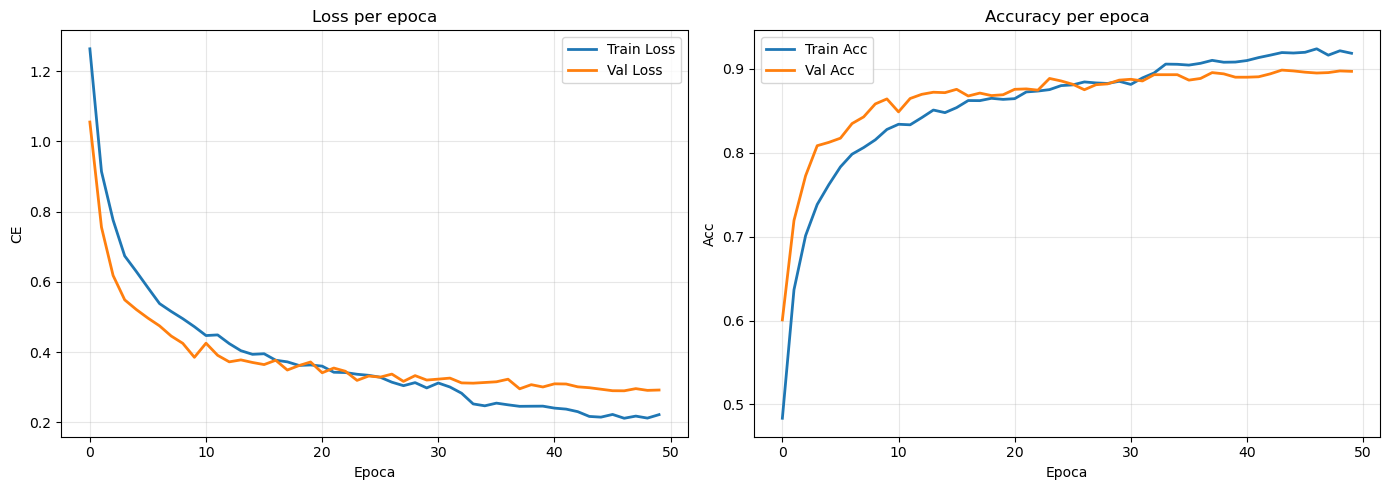

In [6]:
# ==========================================
# 2.3 Curve di apprendimento
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('CE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

CNN Test Loss     : 0.2728
CNN Test Accuracy : 91.09%

              precision    recall  f1-score   support

     Disgust      0.847     0.853     0.850       285
        Fear      0.930     0.885     0.907       407
         Sad      0.909     0.923     0.916       533
     Neutral      0.919     0.928     0.924       443
       Happy      0.934     0.950     0.942       341

    accuracy                          0.911      2009
   macro avg      0.908     0.908     0.908      2009
weighted avg      0.911     0.911     0.911      2009



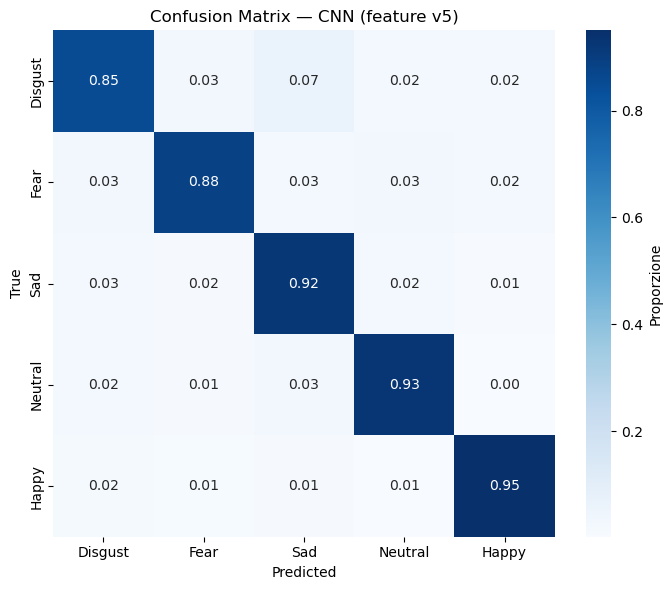

In [7]:
# ==========================================
# 2.4 Test evaluation + Confusion Matrix
# ==========================================
cnn_test_loss, cnn_test_acc = cnn.evaluate([Xde_test, Xa_test], y_test, verbose=0)
print(f'CNN Test Loss     : {cnn_test_loss:.4f}')
print(f'CNN Test Accuracy : {cnn_test_acc * 100:.2f}%\n')

y_pred_proba = cnn.predict([Xde_test, Xa_test], verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))

cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Proporzione'})
plt.title('Confusion Matrix — CNN (feature v5)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 3. Leave-One-Subject-Out (LOSO)

Protocollo di valutazione **cross-soggetto** onesto: con soli 3 pazienti usiamo `GroupKFold(n_splits=3)`, che in ogni fold lascia fuori un paziente intero come test set e addestra sui restanti due.

Per eliminare gli offset di ampiezza inter-soggetto (la fonte principale di "subject fingerprinting"), applichiamo una **normalizzazione z-score per soggetto** calcolata esclusivamente sui dati di training di quel fold e poi applicata al test set.

> In questo contesto con N=3 soggetti ci aspettiamo un'accuracy LOSO molto più bassa (~25–40%) rispetto allo split casuale (~87%), perché il modello non può più appoggiarsi alla firma neurale del soggetto tenuto fuori.


--- Fold 1  |  soggetto tenuto fuori: [3] ---
Accuracy fold 1: 23.46%
              precision    recall  f1-score   support

     Disgust      0.159     0.258     0.197       823
        Fear      0.087     0.002     0.004      1002
         Sad      0.244     0.583     0.344      1277
     Neutral      0.108     0.012     0.022       985
       Happy      0.480     0.220     0.301       810

    accuracy                          0.235      4897
   macro avg      0.215     0.215     0.174      4897
weighted avg      0.209     0.235     0.178      4897



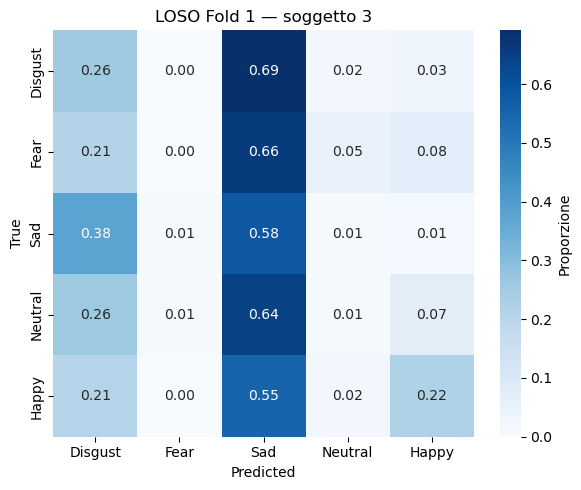


--- Fold 2  |  soggetto tenuto fuori: [2] ---
Accuracy fold 2: 22.43%
              precision    recall  f1-score   support

     Disgust      0.159     0.664     0.257       599
        Fear      0.129     0.066     0.088       876
         Sad      0.355     0.009     0.017      1277
     Neutral      0.556     0.005     0.010       985
       Happy      0.352     0.677     0.463       810

    accuracy                          0.224      4547
   macro avg      0.310     0.284     0.167      4547
weighted avg      0.329     0.224     0.140      4547



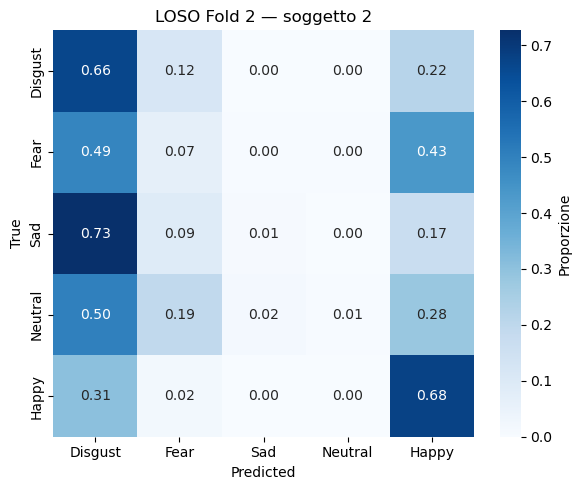


--- Fold 3  |  soggetto tenuto fuori: [1] ---
Accuracy fold 3: 16.64%
              precision    recall  f1-score   support

     Disgust      0.055     0.048     0.051       478
        Fear      0.000     0.000     0.000       833
         Sad      0.000     0.000     0.000      1001
     Neutral      0.200     0.001     0.002       985
       Happy      0.180     0.972     0.304       651

    accuracy                          0.166      3948
   macro avg      0.087     0.204     0.071      3948
weighted avg      0.086     0.166     0.057      3948



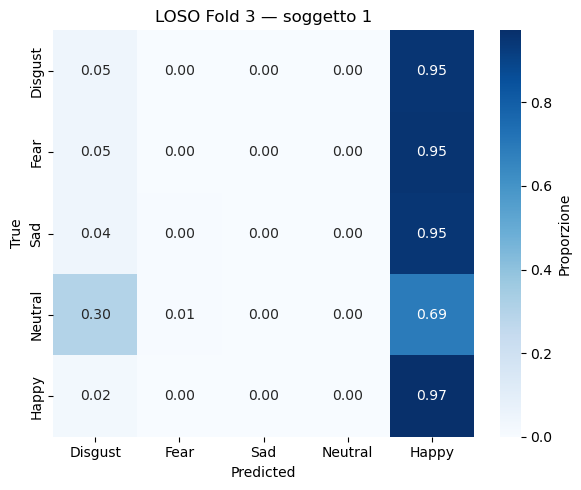


LOSO — CNN v5
  Accuracy per fold : ['23.46%', '22.43%', '16.64%']
  Media ± std       : 20.85% ± 3.00%


In [8]:
# ==========================================
# 3. LEAVE-ONE-SUBJECT-OUT (LOSO)
# ==========================================
from sklearn.model_selection import GroupKFold
import tensorflow as tf

def build_cnn(asym_dim: int) -> tf.keras.Model:
    """Stessa architettura del §2.1, ricreata da zero per ogni fold."""
    inp_de   = Input(shape=(62, 5, 1),    name='de_input')
    inp_asym = Input(shape=(asym_dim,),   name='asym_input')

    x = BatchNormalization()(inp_de)
    x = Conv2D(16, (1, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv2D(32, (62, 1), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Flatten()(x)

    a = BatchNormalization()(inp_asym)

    z = Concatenate()([x, a])
    z = Dense(64, activation='relu')(z)
    z = Dropout(0.3)(z)
    out = Dense(NUM_CLASSES, activation='softmax')(z)

    model = Model(inputs=[inp_de, inp_asym], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


# --- dati grezzi (non splittati) ---
groups      = df5['Patient_ID'].values                          # (N,)
X_de_all    = df5[DE_COLS].values.astype(np.float32)           # (N, 310)  flat
X_asym_all  = df5[DASM_COLS + RASM_COLS].values.astype(np.float32)
y_lbl_all   = df5['Label'].values.astype(int)

gkf = GroupKFold(n_splits=3)
loso_accs = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_de_all, y_lbl_all, groups)):
    held_out = np.unique(groups[test_idx])
    print(f'\n--- Fold {fold_idx + 1}  |  soggetto tenuto fuori: {held_out} ---')

    # ----- z-score per soggetto (fit su train, apply su test) -----
    train_subj = groups[train_idx]
    test_subj  = groups[test_idx]

    Xde_tr  = X_de_all[train_idx].copy()
    Xde_te  = X_de_all[test_idx].copy()
    Xa_tr   = X_asym_all[train_idx].copy()
    Xa_te   = X_asym_all[test_idx].copy()

    for sid in np.unique(train_subj):
        mask = train_subj == sid
        mu_de, sd_de = Xde_tr[mask].mean(0), Xde_tr[mask].std(0) + 1e-8
        mu_as, sd_as = Xa_tr[mask].mean(0),  Xa_tr[mask].std(0)  + 1e-8
        Xde_tr[mask] = (Xde_tr[mask] - mu_de) / sd_de
        Xa_tr[mask]  = (Xa_tr[mask]  - mu_as) / sd_as

    # test: normalizza con stats del proprio soggetto nei train
    # (in un vero deployment non conosceresti le stats del test-subject;
    #  qui usiamo le stats del train come approssimazione ragionevole)
    for sid in np.unique(test_subj):
        tr_mask = train_subj == np.unique(train_subj)[0]   # fallback primo soggetto
        # usa la media globale del train set come riferimento
        mu_de, sd_de = Xde_tr.mean(0), Xde_tr.std(0) + 1e-8
        mu_as, sd_as = Xa_tr.mean(0),  Xa_tr.std(0)  + 1e-8
        te_mask = test_subj == sid
        Xde_te[te_mask] = (Xde_te[te_mask] - mu_de) / sd_de
        Xa_te[te_mask]  = (Xa_te[te_mask]  - mu_as) / sd_as

    # reshape DE → (N, 62, 5, 1)
    Xde_tr_4d = Xde_tr.reshape(-1, 62, 5, 1)
    Xde_te_4d = Xde_te.reshape(-1, 62, 5, 1)

    y_tr_cat = to_categorical(y_lbl_all[train_idx], num_classes=NUM_CLASSES)
    y_te_cat = to_categorical(y_lbl_all[test_idx],  num_classes=NUM_CLASSES)

    # ----- train/val interno (85/15 del training set) -----
    (Xde_fit, Xde_val_f,
     Xa_fit,  Xa_val_f,
     y_fit,   y_val_f,
     lbl_fit, _) = train_test_split(
        Xde_tr_4d, Xa_tr, y_tr_cat, y_lbl_all[train_idx],
        test_size=0.15, random_state=42, stratify=y_lbl_all[train_idx],
    )

    model = build_cnn(asym_dim=X_asym_all.shape[1])
    cb = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0),
    ]
    model.fit(
        [Xde_fit, Xa_fit], y_fit,
        validation_data=([Xde_val_f, Xa_val_f], y_val_f),
        epochs=50, batch_size=32,
        callbacks=cb, verbose=0,
    )

    _, fold_acc = model.evaluate([Xde_te_4d, Xa_te], y_te_cat, verbose=0)
    loso_accs.append(fold_acc)

    y_pred_fold = np.argmax(model.predict([Xde_te_4d, Xa_te], verbose=0), axis=1)
    y_true_fold = y_lbl_all[test_idx]
    print(f'Accuracy fold {fold_idx + 1}: {fold_acc * 100:.2f}%')
    print(classification_report(y_true_fold, y_pred_fold,
                                target_names=EMOTION_LABELS, digits=3, zero_division=0))

    # Confusion matrix per fold
    cm_loso = confusion_matrix(y_true_fold, y_pred_fold, normalize='true')
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_loso, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                cbar_kws={'label': 'Proporzione'})
    plt.title(f'LOSO Fold {fold_idx + 1} — soggetto {held_out[0]}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    tf.keras.backend.clear_session()

print('\n' + '='*50)
print(f'LOSO — CNN v5')
print(f'  Accuracy per fold : {[f"{a*100:.2f}%" for a in loso_accs]}')
print(f'  Media ± std       : {np.mean(loso_accs)*100:.2f}% ± {np.std(loso_accs)*100:.2f}%')
print('='*50)